In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

### False Position Method

Iter  xl              xu              xr                   f(xr)                ea             
1     0.0000000000    -0.9990000000   -0.0016081138        1.1983879807         100.0000000000 
2     -0.0016081138   -0.9990000000   -0.0032114857        1.1967728321         49.9261722884  
3     -0.0032114857   -0.9990000000   -0.0048101260        1.1951544528         33.2348948098  
4     -0.0048101260   -0.9990000000   -0.0064040449        1.1935327412         24.8892532225  
5     -0.0064040449   -0.9990000000   -0.0079932526        1.1919075949         19.8818646511  
6     -0.0079932526   -0.9990000000   -0.0095777588        1.1902789111         16.5436014650  
7     -0.0095777588   -0.9990000000   -0.0111575734        1.1886465867         14.1591232464  
8     -0.0111575734   -0.9990000000   -0.0127327058        1.1870105177         12.3707597824  
9     -0.0127327058   -0.9990000000   -0.0143031656        1.1853706002         10.9798053955  
10    -0.0143031656   -0.9990000000   -0

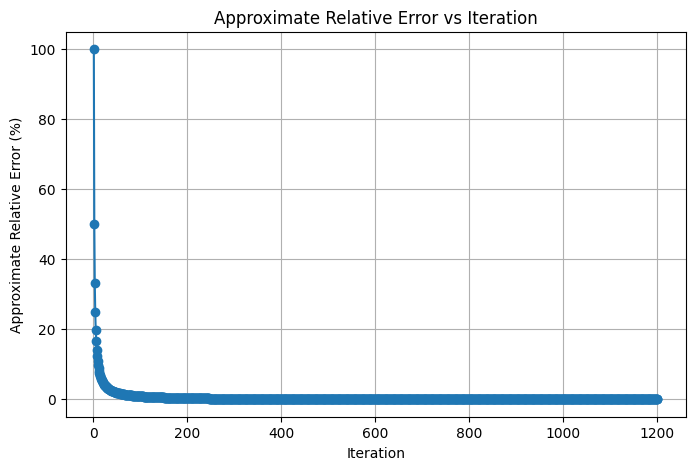

In [43]:
def false(x):
  Kp = 1.2
  a = -8.0
  A = (x**2)/((1 - x)**2)
  B = m.exp(a * x)
  C = np.log(1 + x)
  return Kp - A * B + C

#Given data
xl = 0
xu = -0.999
es = 0.00001
ea = 100
old_root = xl
i = 0

#Plotting Criteria
iterations = []
approx_errors = []

#Find the root
if false(xl) * false(xu) > 0:
  print(f"No root found!")
else:
  print(f"{'Iter':<5} {'xl':<15} {'xu':<15} {'xr':<20} {'f(xr)':<20} {'ea':<15}")
  while ea > es:
    i += 1
    root = (xl*false(xu) - xu*false(xl))/(false(xu) - false(xl))

    ea = abs((root - old_root)/root) * 100
    print(f"{i:<5} {xl:<15.10f} {xu:<15.10f} {root:<20.10f} {false(root):<20.10f} {ea:<15.10f}")

    iterations.append(i)
    approx_errors.append(ea)

    if false(xl)*false(root) < 0:
      xu = root
    else:
      xl = root
    old_root = root
  print(f"\nThe root is {root:.10f} (Approx.)")

#Graph Plot
plt.figure(figsize=(8,5))
plt.plot(iterations, approx_errors, marker='o')
plt.title('Approximate Relative Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Approximate Relative Error (%)')
plt.grid(True)
plt.show()


### Newton-Raphson Method

Iter  xroot           f(xroot)             f'(xroot)            ea             
1     -0.4166586955   -1.7636437663        29.3270748675        20.0022957441  
2     -0.3565216455   -0.4376113210        16.0770243978        16.8677135613  
3     -0.3293019741   -0.0546085517        12.2395619663        8.2658694834   
4     -0.3248403315   -0.0012012520        11.7051111895        1.3734879015   
5     -0.3247377052   -0.0000006164        11.6931000895        0.0316028225   
6     -0.3247376525   -0.0000000000        11.6930939228        0.0000162340   
7     -0.3247376525   -0.0000000000        11.6930939228        0.0000000000   

The root is -0.3247376525 (Approx.)


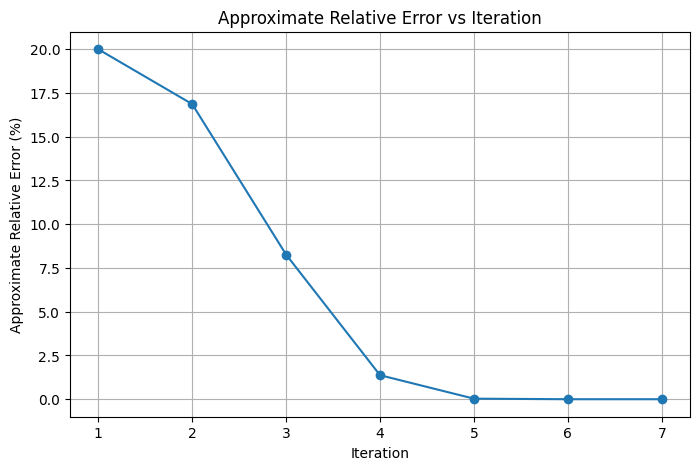

In [30]:
def new(x):
  Kp = 1.2
  a = -8.0
  A = (x**2)/((1 - x)**2)
  B = m.exp(a * x)
  C = np.log(1 + x)
  return Kp - A * B + C

def new_der(x):
  A = (2*x*((1-x)**2) + 2*(x**2)*(1 - x)) / ((1 - x)**4)
  B = m.exp(-8.0 * x)
  C = 8*(x**2) / ((1 - x)**2)
  D = 1 / (1 + x)
  return - (A * B - C * B) + D

#Given data
x0 = -0.5
es = 0.00001
ea = 100
i = 0

#Plotting Criteria
iterations = []
approx_errors = []

#Find the root
print(f"{'Iter':<5} {'xroot':<15} {'f(xroot)':<20} {'f\'(xroot)':<20} {'ea':<15}")
while ea > es:
  i += 1
  if new_der(x0) == 0:
    print("Derivative is 0")
    break
  else:
    xroot = x0 - (new(x0) / new_der(x0))
    ea = abs((xroot - x0)/xroot) * 100
  print(f"{i:<5} {xroot:<15.10f} {new(xroot):<20.10f} {new_der(xroot):<20.10f} {ea:<15.10f}")

  iterations.append(i)
  approx_errors.append(ea)

  x0 = xroot

print(f"\nThe root is {xroot:.10f} (Approx.)")

#Graph Plot
plt.figure(figsize=(8,5))
plt.plot(iterations, approx_errors, marker='o')
plt.title('Approximate Relative Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Approximate Relative Error (%)')
plt.grid(True)
plt.show()

### Secant Method

Iter  x0              x1              xk              f(xk)                f'(xk)               ea             
1     -0.3000000000   -0.7000000000   -0.3022232560   0.2357556821         9.3396028478         131.6168548249 
2     -0.7000000000   -0.3022232560   -0.3042579047   0.2165590994         9.5307389689         0.6687250364   
3     -0.3022232560   -0.3042579047   -0.3272110374   -0.0292823427        11.9860818994        7.0147794572   
4     -0.3042579047   -0.3272110374   -0.3244770740   0.0030430007         11.6626526976        0.8425752018   
5     -0.3272110374   -0.3244770740   -0.3247344403   0.0000375603         11.6927181745        0.0792543756   
6     -0.3244770740   -0.3247344403   -0.3247376567   -0.0000000490        11.6930944127        0.0009904660   
7     -0.3247344403   -0.3247376567   -0.3247376525   0.0000000000         11.6930939228        0.0000012899   

The root is -0.3247376525 (Approx.)


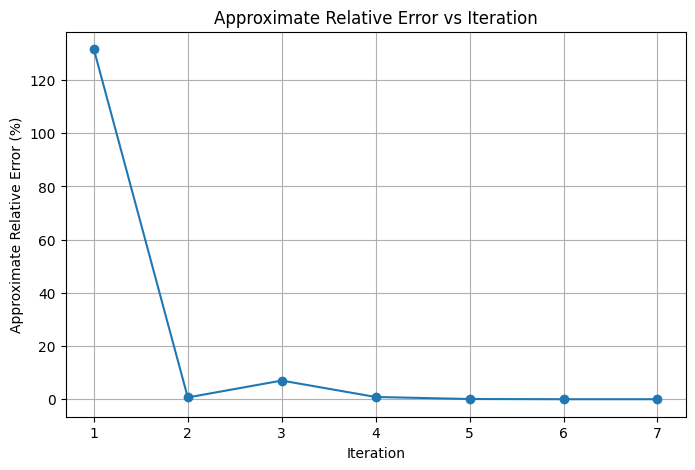

In [18]:
def sec(x):
  Kp = 1.2
  a = -8.0
  A = (x**2)/((1 - x)**2)
  B = m.exp(a * x)
  C = np.log(1 + x)
  return Kp - A * B + C

def sec_der(x):
  A = (2*x*((1-x)**2) + 2*(x**2)*(1 - x)) / ((1 - x)**4)
  B = m.exp(-8.0 * x)
  C = 8*(x**2) / ((1 - x)**2)
  D = 1 / (1 + x)
  return - (A * B - C * B) + D

#Given data
x0 = -0.3
x1 = -0.7
es = 0.00001
ea = 100
i = 0

#Plotting Criteria
iterations = []
approx_errors = []

#Find root
print(f"{'Iter':<5} {'x0':<15} {'x1':<15} {'xk':<15} {'f(xk)':<20} {'f\'(xk)':<20} {'ea':<15}")
while ea > es:
  i += 1
  xk = x1 - sec(x1) * ((x1 - x0) / (sec(x1) - sec(x0)))

  ea = abs((xk - x1)/xk) * 100
  print(f"{i:<5} {x0:<15.10f} {x1:<15.10f} {xk:<15.10f} {sec(xk):<20.10f} {sec_der(xk):<20.10f} {ea:<15.10f}")

  iterations.append(i)
  approx_errors.append(ea)

  x0 = x1
  x1 = xk

print(f"\nThe root is {xk:.10f} (Approx.)")

#Graph Plot
plt.figure(figsize=(8,5))
plt.plot(iterations, approx_errors, marker='o')
plt.title('Approximate Relative Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Approximate Relative Error (%)')
plt.grid(True)
plt.show()